# Koopman Operator Training with Autoencoder

This notebook implements a training pipeline for a Koopman operator model combined with an autoencoder. The code includes data loading, model definition, training, and visualization of results such as trajectories and eigenvalues.


In [1]:
import os

os.chdir('..')

import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.init as init
import torch.multiprocessing as mp

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from utils.Viz import *
from KoopmanTrainer import Trainer
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.koopman_operator import Knet

# Set multiprocessing start method
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass  # method already set

# Disable deterministic algorithms for flexibility
torch.use_deterministic_algorithms(False)


## Training Settings

Configure the training settings, including random seeds for reproducibility and device selection (CUDA or CPU).

In [2]:
# Get arguments (assuming get_args() handles command-line or default args)
args = get_args()

# Set seeds for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
set_seed(args.seed)

# Device configuration
device = get_device()

Using the CPU


In [3]:
# editing the args 
args.dataset = 'simple'
args.folder = 'simple'
args.bottleneck = 3
args.decoder_loss_weight = 100
args.lr = 0.001
args.epochs = 300
args.unitary_loss_weight = 1
args.prediction_length = 5
args.encoder_hidden_layers = [50 , 50]

## Create Experiment Folder

Set up the folder structure to save experiment results, including arguments in a JSON file.

In [4]:
# Create experiment folder
experiment_folder = 'experiments'
if not os.path.isdir(experiment_folder):
    os.mkdir(experiment_folder)

folder_path = os.path.join(experiment_folder, args.folder)
os.makedirs(folder_path, exist_ok=True)

# Save arguments to JSON
args_dict = vars(args)
with open(os.path.join(folder_path, 'args.json'), 'w') as f:
    json.dump(args_dict, f,indent=2)

## Load and Prepare Dataset

Load and preprocess the dataset using the `KoopmanDataHandler` class, then create data loaders for training, validation, and testing.

In [5]:
# Convert args to a dictionary for the data handler

config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": args.normalize,
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta
}

# Initialize data handler
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get data dimensions for model initialization
input_size = preprocessed_data['Xtrain'].shape[-1]

100%|██████████| 500/500 [00:00<00:00, 35283.61it/s]

the shape of the data is torch.Size([500, 51, 3])
Processing dataset: simple
train_idx: 400, val_idx: 450
Processed data shapes - Train: torch.Size([400, 51, 3]), Val: torch.Size([50, 51, 3]), Test: torch.Size([50, 51, 3])



/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:130: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:132: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().

## Model Definition

Define the autoencoder (`AutoEncoder`) and Koopman operator (`Knet`), then combine them into a `ModuleDict`.

In [6]:
# Model definition
ae = AutoEncoder(
    input_size=input_size,
    encoded_size=args.bottleneck,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet = Knet(size=args.bottleneck)

# Combine AE and Knet as a ModuleDict
model = torch.nn.ModuleDict({'ae': ae, 'knet': knet})
model = model.to(device)

## Model Summary

Display the total number of parameters and the model architecture.

In [7]:
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model.parameters())/1000.0))
print('************')

print('**** Model Architecture ****')
print(model)
print('***************************')

**** Setup ****
Total params: 0.01M
Total params: 5.82k
************
**** Model Architecture ****
ModuleDict(
  (ae): AutoEncoder(
    (encoder): MLP(
      (net): ModuleList(
        (0): Linear(in_features=3, out_features=50, bias=True)
        (1): ReLU()
        (2): Linear(in_features=50, out_features=50, bias=True)
        (3): ReLU()
        (4): Linear(in_features=50, out_features=3, bias=True)
      )
    )
    (decoder): MLP(
      (net): ModuleList(
        (0): Linear(in_features=3, out_features=50, bias=True)
        (1): ReLU()
        (2): Linear(in_features=50, out_features=50, bias=True)
        (3): ReLU()
        (4): Linear(in_features=50, out_features=3, bias=True)
      )
    )
  )
  (knet): Knet(
    (net): Linear(in_features=3, out_features=3, bias=False)
  )
)
***************************


## Load from Checkpoint

Optionally load a pre-trained model from a checkpoint if specified.

In [8]:
if args.load_from_checkpoint:
    checkpoint_path = os.path.join(folder_path, 'model.pkl')
    if os.path.isfile(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))
        print(f'Model loaded from {checkpoint_path}')
    else:
        print(f'No checkpoint found at {checkpoint_path}')

## Training

Train the model using the `Trainer` class with the specified data loaders.

In [9]:
trainer = Trainer(model, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)
trainer.train_KoopmanAE()

Using the CPU


Training Epochs:   7%|▋         | 22/300 [00:01<00:15, 17.91it/s]

Epoch 20/300
Training - Recon Loss: 3.477748e-04, Linear Loss: 3.623486e-03, Pred Loss: 3.112606e-03, Unitary Loss: 1.250808e-01, Total Loss: 4.747423e-01
Validation - Recon Loss: 2.278555e-04, Linear Loss: 2.972666e-03, Pred Loss: 2.477243e-03,Unitary Loss: 1.247424e-01, Total Loss: 2.734825e-01


Training Epochs:  14%|█▍        | 42/300 [00:02<00:13, 18.75it/s]

Epoch 40/300
Training - Recon Loss: 8.772064e-05, Linear Loss: 2.139057e-03, Pred Loss: 2.549295e-03, Unitary Loss: 1.188948e-01, Total Loss: 3.847354e-01
Validation - Recon Loss: 8.307863e-05, Linear Loss: 1.754923e-03, Pred Loss: 1.977272e-03,Unitary Loss: 1.187126e-01, Total Loss: 2.077900e-01


...

Training Epochs:  94%|█████████▍| 282/300 [00:15<00:01, 17.94it/s]

Epoch 280/300
Training - Recon Loss: 4.139455e-05, Linear Loss: 1.203429e-04, Pred Loss: 6.117154e-05, Unitary Loss: 1.872179e-02, Total Loss: 2.909874e-02
Validation - Recon Loss: 2.890494e-05, Linear Loss: 9.464659e-05, Pred Loss: 4.811736e-05,Unitary Loss: 1.869629e-02, Total Loss: 7.796876e-03


Training Epochs: 100%|██████████| 300/300 [00:16<00:00, 18.75it/s]


Epoch 300/300
Training - Recon Loss: 3.655921e-05, Linear Loss: 1.188427e-04, Pred Loss: 5.771494e-05, Unitary Loss: 1.841003e-02, Total Loss: 2.795628e-02
Validation - Recon Loss: 4.703004e-05, Linear Loss: 9.845506e-05, Pred Loss: 6.178724e-05,Unitary Loss: 1.858851e-02, Total Loss: 1.098018e-02


(ModuleDict(
   (ae): AutoEncoder(
     (encoder): MLP(
       (net): ModuleList(
         (0): Linear(in_features=3, out_features=50, bias=True)
         (1): ReLU()
         (2): Linear(in_features=50, out_features=50, bias=True)
         (3): ReLU()
         (4): Linear(in_features=50, out_features=3, bias=True)
       )
     )
     (decoder): MLP(
       (net): ModuleList(
         (0): Linear(in_features=3, out_features=50, bias=True)
         (1): ReLU()
         (2): Linear(in_features=50, out_features=50, bias=True)
         (3): ReLU()
         (4): Linear(in_features=50, out_features=3, bias=True)
       )
     )
   )
   (knet): Knet(
     (net): Linear(in_features=3, out_features=3, bias=False)
   )
 ),
 AdamW (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.0004096000000000001
     maximize: False
     weight_decay: 0.0
 ),
 {'recon_loss_tr': [0.

In [10]:
# test the model
trainer.test_KoopmanAE(test_loader)

Test - Recon Loss: 7.489591e-05, Linear Loss: 1.431197e-04, Pred Loss: 7.967632e-05, Total Loss: 1.560034e-02


## Visualization

Visualize the original, reconstructed, and predicted trajectories from the test set.

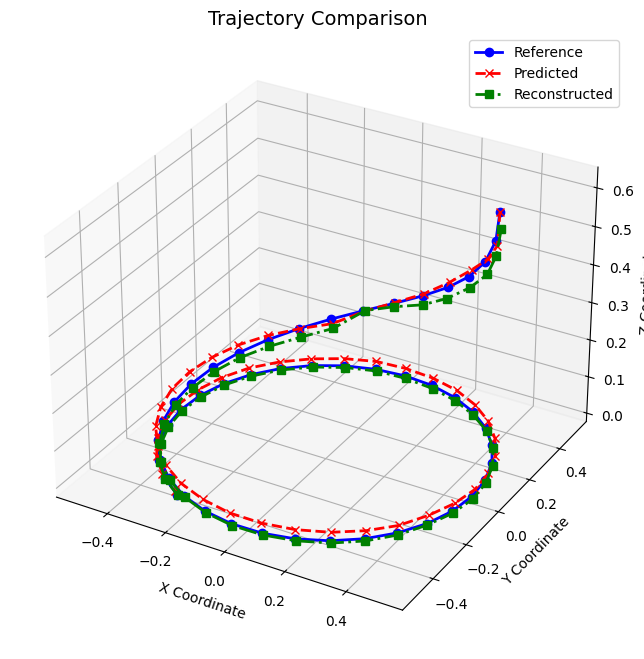

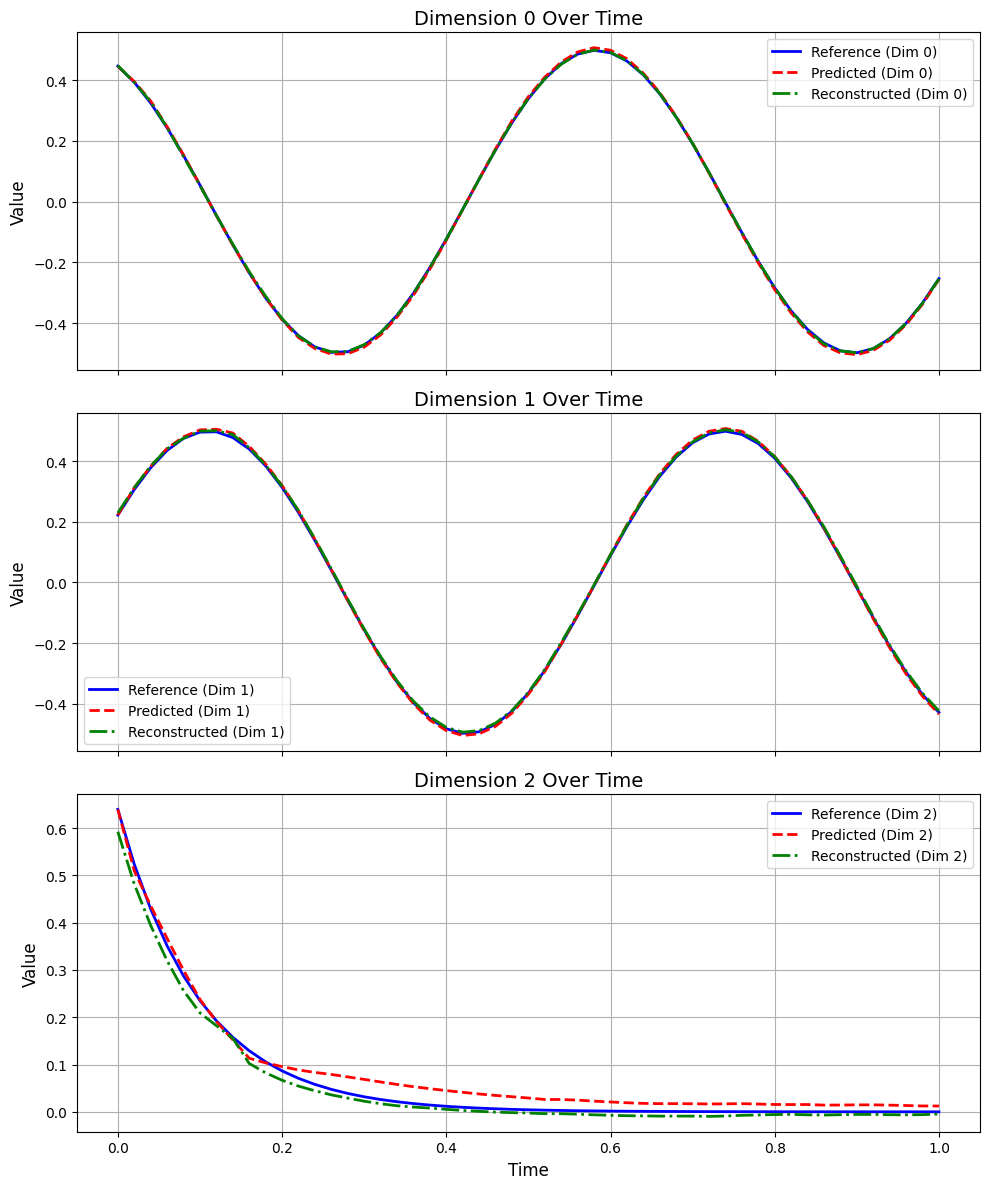

In [11]:
# for saving the results first

# Get a test sample
traj = preprocessed_data["Xtest"][3].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=True)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=True)

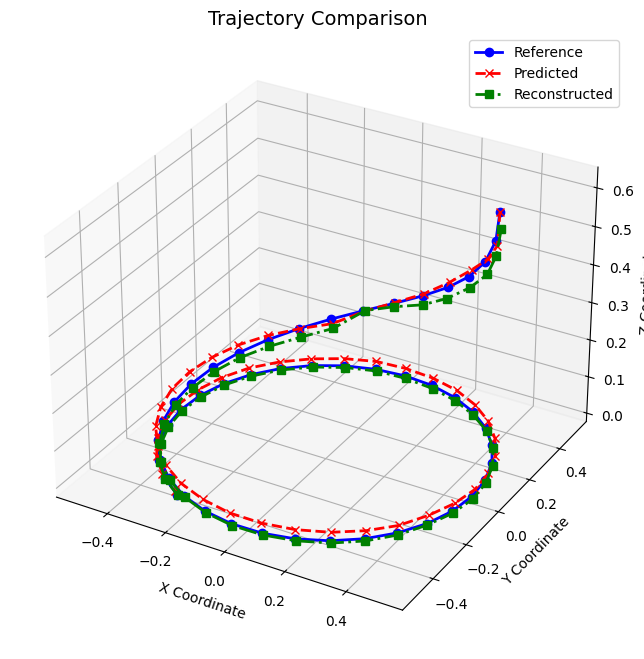

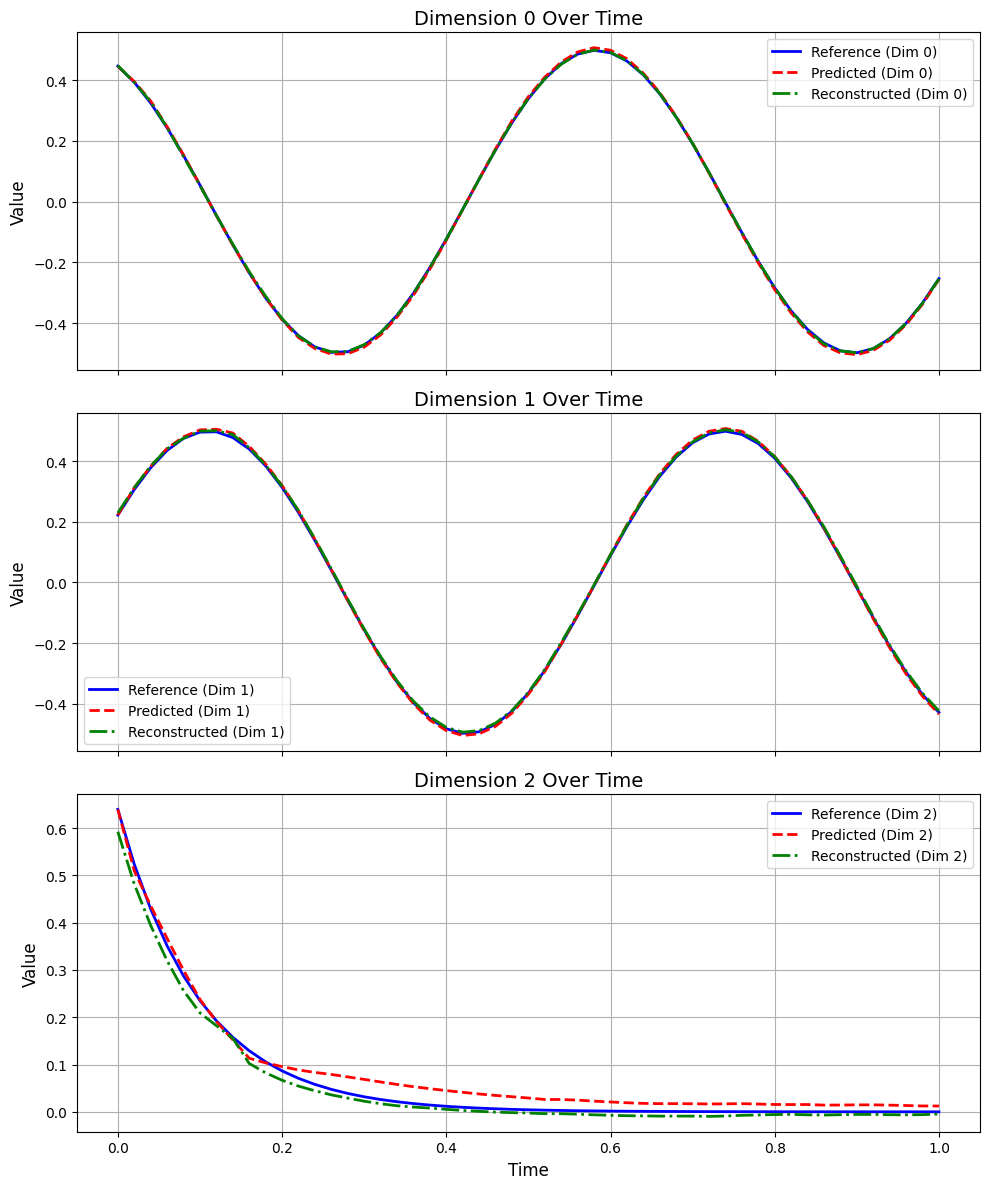

In [19]:
# Get a test sample
#traj = preprocessed_data["Xtest"][32].to(device)
traj = preprocessed_data["Xtest"][3].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Eigenvalues Visualization

Compute and visualize the eigenvalues of the Koopman operator on a unit circle.

Eigenvalues:
[0.97997624-0.19889586j 0.97997624+0.19889586j 0.912482  +0.j        ]
Training and evaluation completed. Results saved in experiments/simple


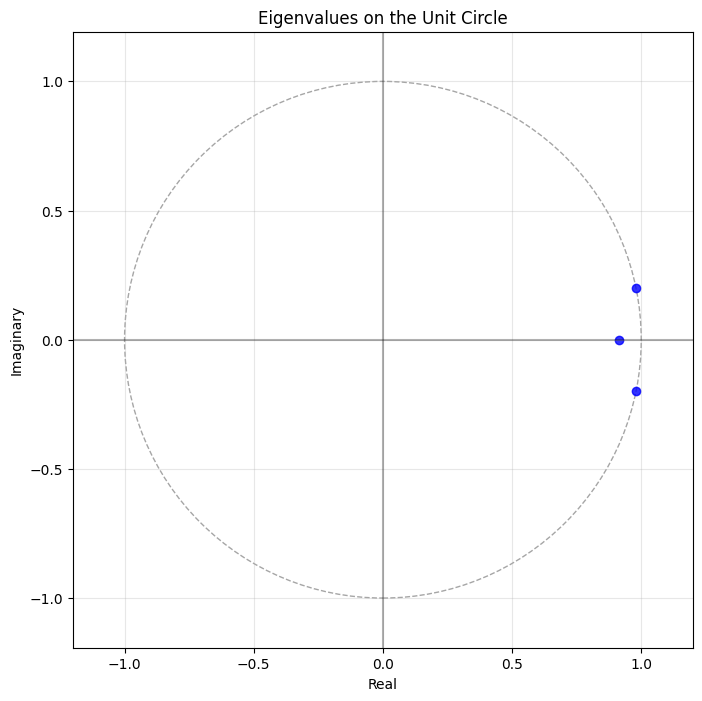

In [13]:
# Compute eigenvalues
eigenvalues, eigenvectors = torch.linalg.eig(model.knet.net.weight)
eigenvalues = eigenvalues.cpu().detach().numpy()
idx = np.argsort(eigenvalues.real)[::-1]
eigenvalues = eigenvalues[idx]

# Print eigenvalues
print('Eigenvalues:')
print(eigenvalues)

# Plot eigenvalues on unit circle
plot_eigenvalues_on_unit_circle(eigenvalues, folder_path)

print(f"Training and evaluation completed. Results saved in {folder_path}")

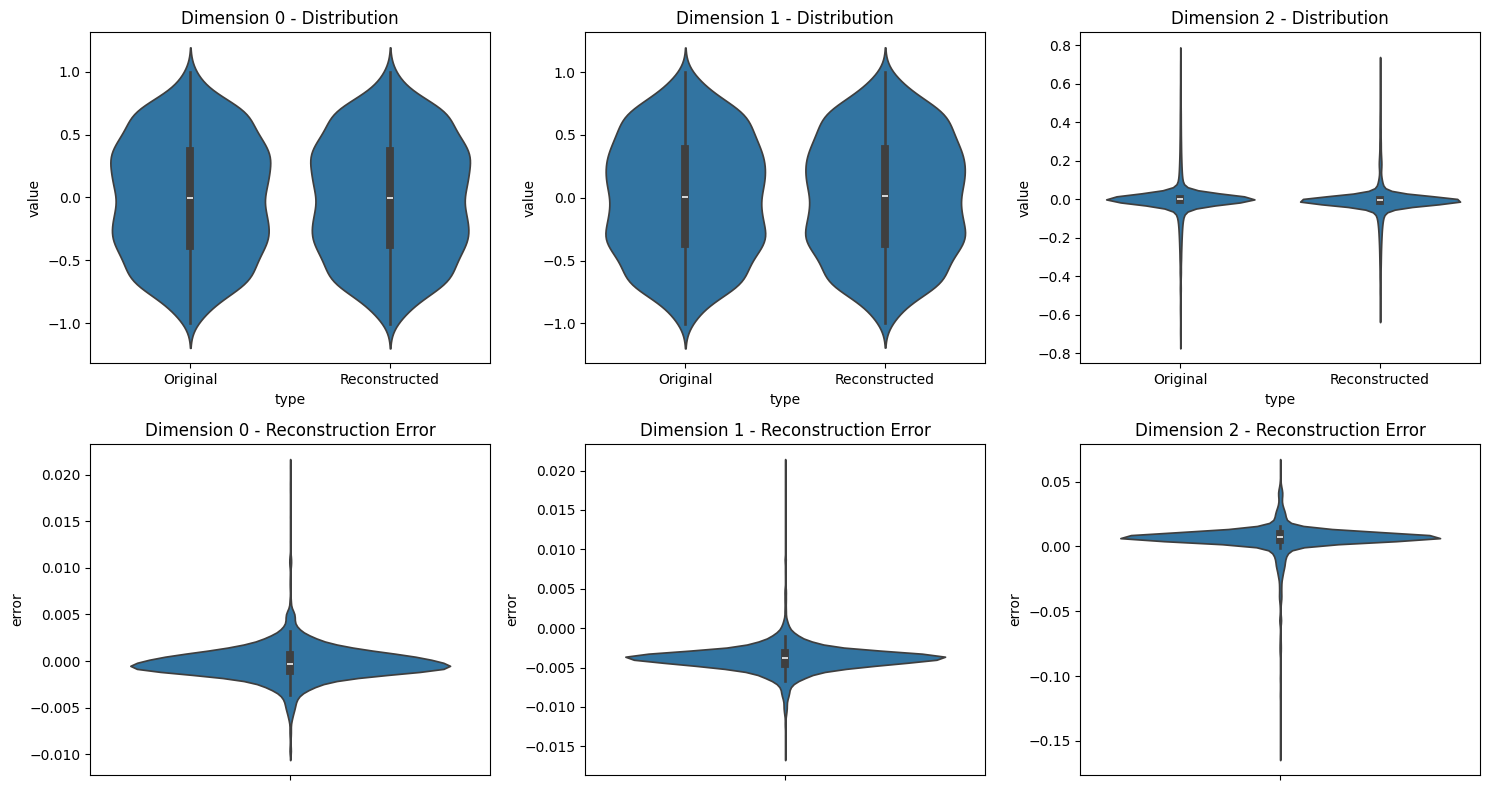

In [14]:
violin_plot(model, preprocessed_data["Xtest"], device, folder_path)